**Load & Explore Dataset**

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set Seaborn style
sns.set(style="whitegrid")
# Load dataset
df = pd.read_csv("online_retail_II.csv")

# Quick look
print(df.head())
print(df.info())

# Check missing values
print(df.isnull().sum())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice 

**Data Cleaning**

*   Remove missing Customer IDs
*   Remove negative/zero quantities (returns, errors)









In [ ]:
# Drop rows with missing customer IDs
df = df.dropna(subset=['Customer ID'])

# Remove returns (negative quantities)
df = df[df['Quantity'] > 0]

# Create a new column: Total Price
df['TotalPrice'] = df['Quantity'] * df['Price']


**Sales Trend Analysis**

MonthYear
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Freq: M, Name: TotalPrice, dtype: float64


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='MonthYear'>

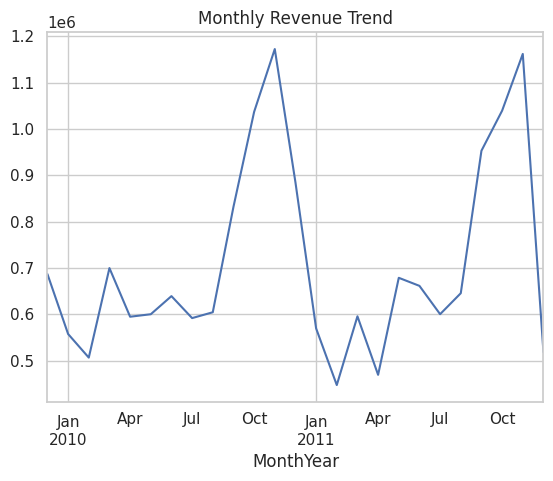

In [ ]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Month-Year
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

# Group by Month-Year
monthly_sales = df.groupby('MonthYear')['TotalPrice'].sum()

print(monthly_sales)
monthly_sales.plot(kind='line', title="Monthly Revenue Trend")


**Top Products & Customers**

In [ ]:
# Top 10 Products by Sales
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_products)

# Top 10 Customers by Revenue
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)



Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                152340.57
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
POSTAGE                               126563.04
PARTY BUNTING                         103880.23
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79594.33
Name: TotalPrice, dtype: float64
Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalPrice, dtype: float64


**Pareto Analysis (80/20 Rule)**

In [ ]:
# Customer revenue
customer_revenue = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# Calculate cumulative revenue %
customer_revenue['cum_revenue_perc'] = (customer_revenue['TotalPrice'].cumsum() / customer_revenue['TotalPrice'].sum()) * 100

# Find % of customers making 80% revenue
top_customers_count = (customer_revenue['cum_revenue_perc'] <= 80).sum()
total_customers = customer_revenue.shape[0]

print(f"{top_customers_count} customers ({(top_customers_count/total_customers)*100:.2f}%) contribute to 80% of revenue.")


814 customers (30.45%) contribute to 80% of revenue.


**Visualization & Dashboard**

* Use Matplotlib/Seaborn/Plotly in Python for charts.

* Or create a Tableau/Power BI dashboard showing:

* Monthly revenue trend

* Top products

* Top customers

* Country-wise sales


**Top 10 Products by Revenue**

/tmp/ipython-input-842038971.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


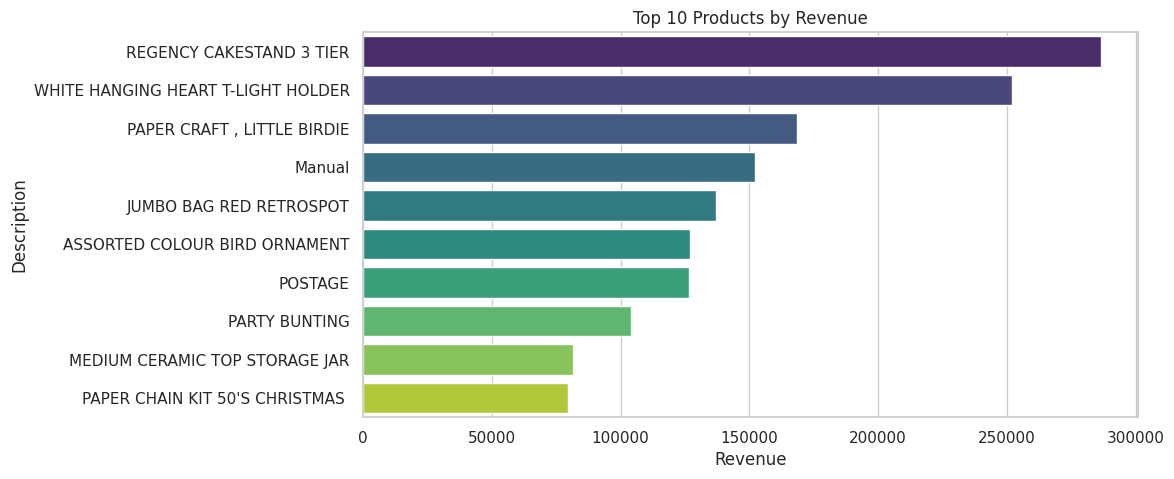

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.show()



**Analyze and visualize top countries**

- Country with highest sales: United Kingdom


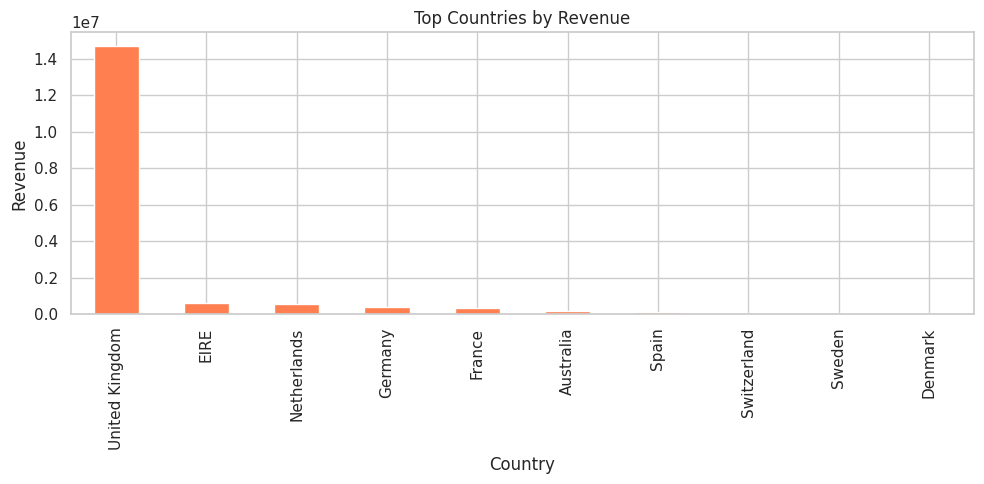

In [ ]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(f"- Country with highest sales: {top_countries.index[0]}") # Uncommented this line

# Visualize top countries
top_countries.plot(kind='bar', figsize=(10, 5), title='Top Countries by Revenue', color='coral')
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

****

**Pareto Analysis**

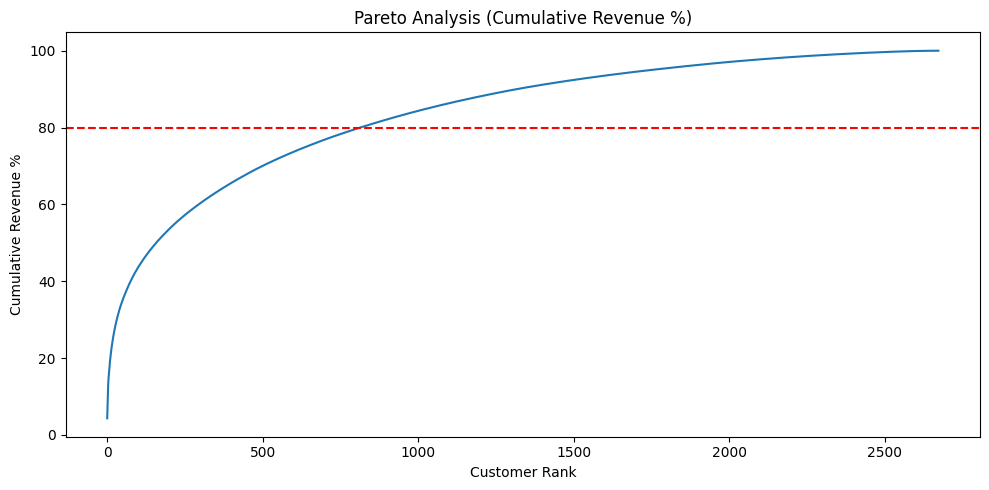

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=customer_revenue, x=customer_revenue.index, y='cum_revenue_perc')
plt.axhline(y=80, color='red', linestyle='--')
plt.title('Pareto Analysis (Cumulative Revenue %)')
plt.xlabel("Customer Rank")
plt.ylabel("Cumulative Revenue %")
plt.tight_layout()
plt.show()